# EDA — 21 Active Matches (15-class, 3-way split)

Updated analysis reflecting:
- **15-class shot type vocabulary** (official ShuttleSet English names, drive subtypes merged)
- **3-way split**: 17 train / 2 val / 2 test (val carved from train pool)
- Fixed rally counting (set-aware)

Sections:
1. Setup & Load Annotations
2. Per-Split Summary
3. Shot Type Distribution (15-class, merged drive)
4. Per-Match Shot Counts
5. Rally Length Distribution
6. Shot Duration by Type
7. Class Imbalance Analysis
8. Summary

In [1]:
import sys, json
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

from src.config import (
    SS_CSV_ROOT, SS_MATCH_CSV, SS_SPLIT_JSON,
    SS_SKELETONS_GDINO, SS_SHUTTLES,
    SHOT_TYPES, SHOT_TYPE_TO_IDX, SS_TYPE_TO_SHOT_TYPE, NUM_SHOT_TYPES,
)

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 10
plt.rcParams['figure.facecolor'] = 'white'

# Validation matches (carved from train pool at training time)
VAL_MATCHES = {
    'NG_Ka_Long_Angus_Jonatan_CHRISTIE_Malaysia_Masters_2020_QuarterFinals',
    'Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_OPEN_2021_QuarterFinals',
}

SPLIT_COLORS = {'train': '#22c55e', 'val': '#f59e0b', 'test': '#a78bfa'}
SPLIT_LABELS = {'train': 'Train (17)', 'val': 'Val (2)', 'test': 'Test (2)'}

print(f"Shot types ({NUM_SHOT_TYPES}): {SHOT_TYPES}")

Shot types (15): ['net shot', 'return net', 'smash', 'wrist smash', 'lob', 'defensive return lob', 'clear', 'drive', 'drop', 'passive drop', 'push', 'rush', 'cross-court net shot', 'short service', 'long service']


## 1. Load Split & CSV Annotations

In [2]:
split_data = json.loads(SS_SPLIT_JSON.read_text())

# 3-way split
active_matches = {}
for m in split_data.get('train', []):
    active_matches[m] = 'val' if m in VAL_MATCHES else 'train'
for m in split_data.get('held_out', []):
    active_matches[m] = 'test'

for sp in ('train', 'val', 'test'):
    n = sum(1 for v in active_matches.values() if v == sp)
    print(f"  {sp:6s}: {n} matches")

# Load match metadata
match_meta = pd.read_csv(SS_MATCH_CSV)
match_meta['video'] = match_meta['video'].str.strip()
match_meta = match_meta[match_meta['video'].isin(active_matches)].copy()
match_meta['split'] = match_meta['video'].map(active_matches)
print(f"\nMatch metadata: {len(match_meta)} rows")

# Load all CSV stroke annotations (set-aware rally ID)
csv_root = Path(SS_CSV_ROOT)
all_records = []
for match_id, sp in sorted(active_matches.items()):
    match_dir = csv_root / match_id
    if not match_dir.exists():
        print(f"  [WARN] Missing CSV dir: {match_id}")
        continue
    for csv_path in sorted(match_dir.glob('set*.csv')):
        try:
            set_num = int(''.join(filter(str.isdigit, csv_path.stem)) or '0')
        except ValueError:
            set_num = 0
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        df['match_id'] = match_id
        df['split']    = sp
        df['set_num']  = set_num
        # Globally unique rally ID within a match (set-aware)
        df['rally_uid'] = df['set_num'].astype(str) + '_' + df['rally'].astype(str)
        all_records.append(df)

strokes = pd.concat(all_records, ignore_index=True)

# Map Chinese type → 15-class label (drive subtypes merged)
strokes['shot_type'] = strokes['type'].map(SS_TYPE_TO_SHOT_TYPE)

print(f"\nTotal strokes loaded : {len(strokes):,}")
print(f"Labelled strokes     : {strokes['shot_type'].notna().sum():,}")
print(f"Unknown/unmapped     : {strokes['shot_type'].isna().sum():,}")
strokes.head(3)

  train : 17 matches
  val   : 2 matches
  test  : 2 matches

Match metadata: 21 rows

Total strokes loaded : 17,754
Labelled strokes     : 16,974
Unknown/unmapped     : 780


,rally,ball_round,time,frame_num,roundscore_A,roundscore_B,player,server,type,aroundhead,...,player_location_y,opponent_location_area,opponent_location_x,opponent_location_y,db,match_id,split,set_num,rally_uid,shot_type
0,1,1.0,00:06:31,11754.0,1,0,A,1,發長球,NaN,...,381.0,8.0,747.0,557.0,0,Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_O...,val,1,1_1,long service
1,1,2.0,00:06:32,11788.0,1,0,B,2,點扣,NaN,...,622.0,8.0,632.0,359.0,0,Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_O...,val,1,1_1,wrist smash
2,1,3.0,00:06:34,11825.0,1,0,A,2,擋小球,NaN,...,367.0,8.0,775.0,614.0,0,Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_O...,val,1,1_1,return net


## 2. Per-Split Summary

In [3]:
# Use set-aware rally_uid for correct rally counts
split_summary = strokes.groupby('split').agg(
    matches  =('match_id', 'nunique'),
    rallies  =('rally_uid', lambda x: x[strokes.loc[x.index, 'match_id'].map(
                   lambda m: True)].nunique()),
    shots    =('type', 'count'),
    labelled =('shot_type', 'count'),
).reindex(['train', 'val', 'test'])

# Simpler: compute rallies via set-aware groupby
rally_uid_counts = (strokes.groupby(['split', 'match_id', 'rally_uid'])
                    .size().reset_index(name='n'))
rally_per_split  = rally_uid_counts.groupby('split')['rally_uid'].count()
split_summary['rallies'] = rally_per_split

split_summary['shots_pct'] = (split_summary['shots'] / split_summary['shots'].sum() * 100).round(1)
split_summary['avg_shots_per_rally'] = (split_summary['shots'] / split_summary['rallies']).round(1)

print("=" * 70)
print("SPLIT SUMMARY")
print("=" * 70)
print(split_summary[['matches','rallies','shots','labelled','shots_pct','avg_shots_per_rally']].to_string())
print(f"\nTotal: {split_summary['matches'].sum()} matches, "
      f"{split_summary['rallies'].sum()} rallies, "
      f"{split_summary['shots'].sum():,} shots")

# Per-match breakdown
print("\n" + "-"*70)
per_match = (strokes.groupby(['split', 'match_id'])
             .agg(shots=('type','count'),
                  rallies=('rally_uid','nunique'))
             .reset_index()
             .sort_values(['split','shots'], ascending=[True,False]))
for sp in ('train', 'val', 'test'):
    sub = per_match[per_match['split'] == sp]
    print(f"\n{sp.upper()} ({len(sub)} matches, {sub['shots'].sum():,} shots, {sub['rallies'].sum()} rallies):")
    for _, r in sub.iterrows():
        short = r['match_id'].replace('_',' ')[:55]
        print(f"  {r['shots']:5d} shots  {r['rallies']:3d} rallies  {short}")

SPLIT SUMMARY
       matches  rallies  shots  labelled  shots_pct  avg_shots_per_rally
split                                                                   
train       17     1421  13924     13270       78.4                  9.8
val          2      212   2155      2077       12.1                 10.2
test         2      178   1675      1627        9.4                  9.4

Total: 21 matches, 1811 rallies, 17,754 shots

----------------------------------------------------------------------

TRAIN (17 matches, 13,924 shots, 1421 rallies):
   1273 shots  115 rallies  Hans-Kristian Solberg Vittinghus Lee Cheuk Yu TOYOTA TH
   1219 shots  111 rallies  CHOU Tien Chen Jonatan CHRISTIE Indonesia Open 2019 Qua
   1200 shots  112 rallies  Ng Ka Long Angus Kidambi Srikanth HSBC BWF WORLD TOUR F
   1095 shots  107 rallies  Viktor Axelsen Anthony Sinisuka Ginting YONEX Thailand 
    910 shots  107 rallies  Viktor AXELSEN CHEN Long Malaysia Masters 2020 QuarterF
    895 shots  101 rallies  Ander

## 3. Shot Type Distribution (15-class, drive merged)

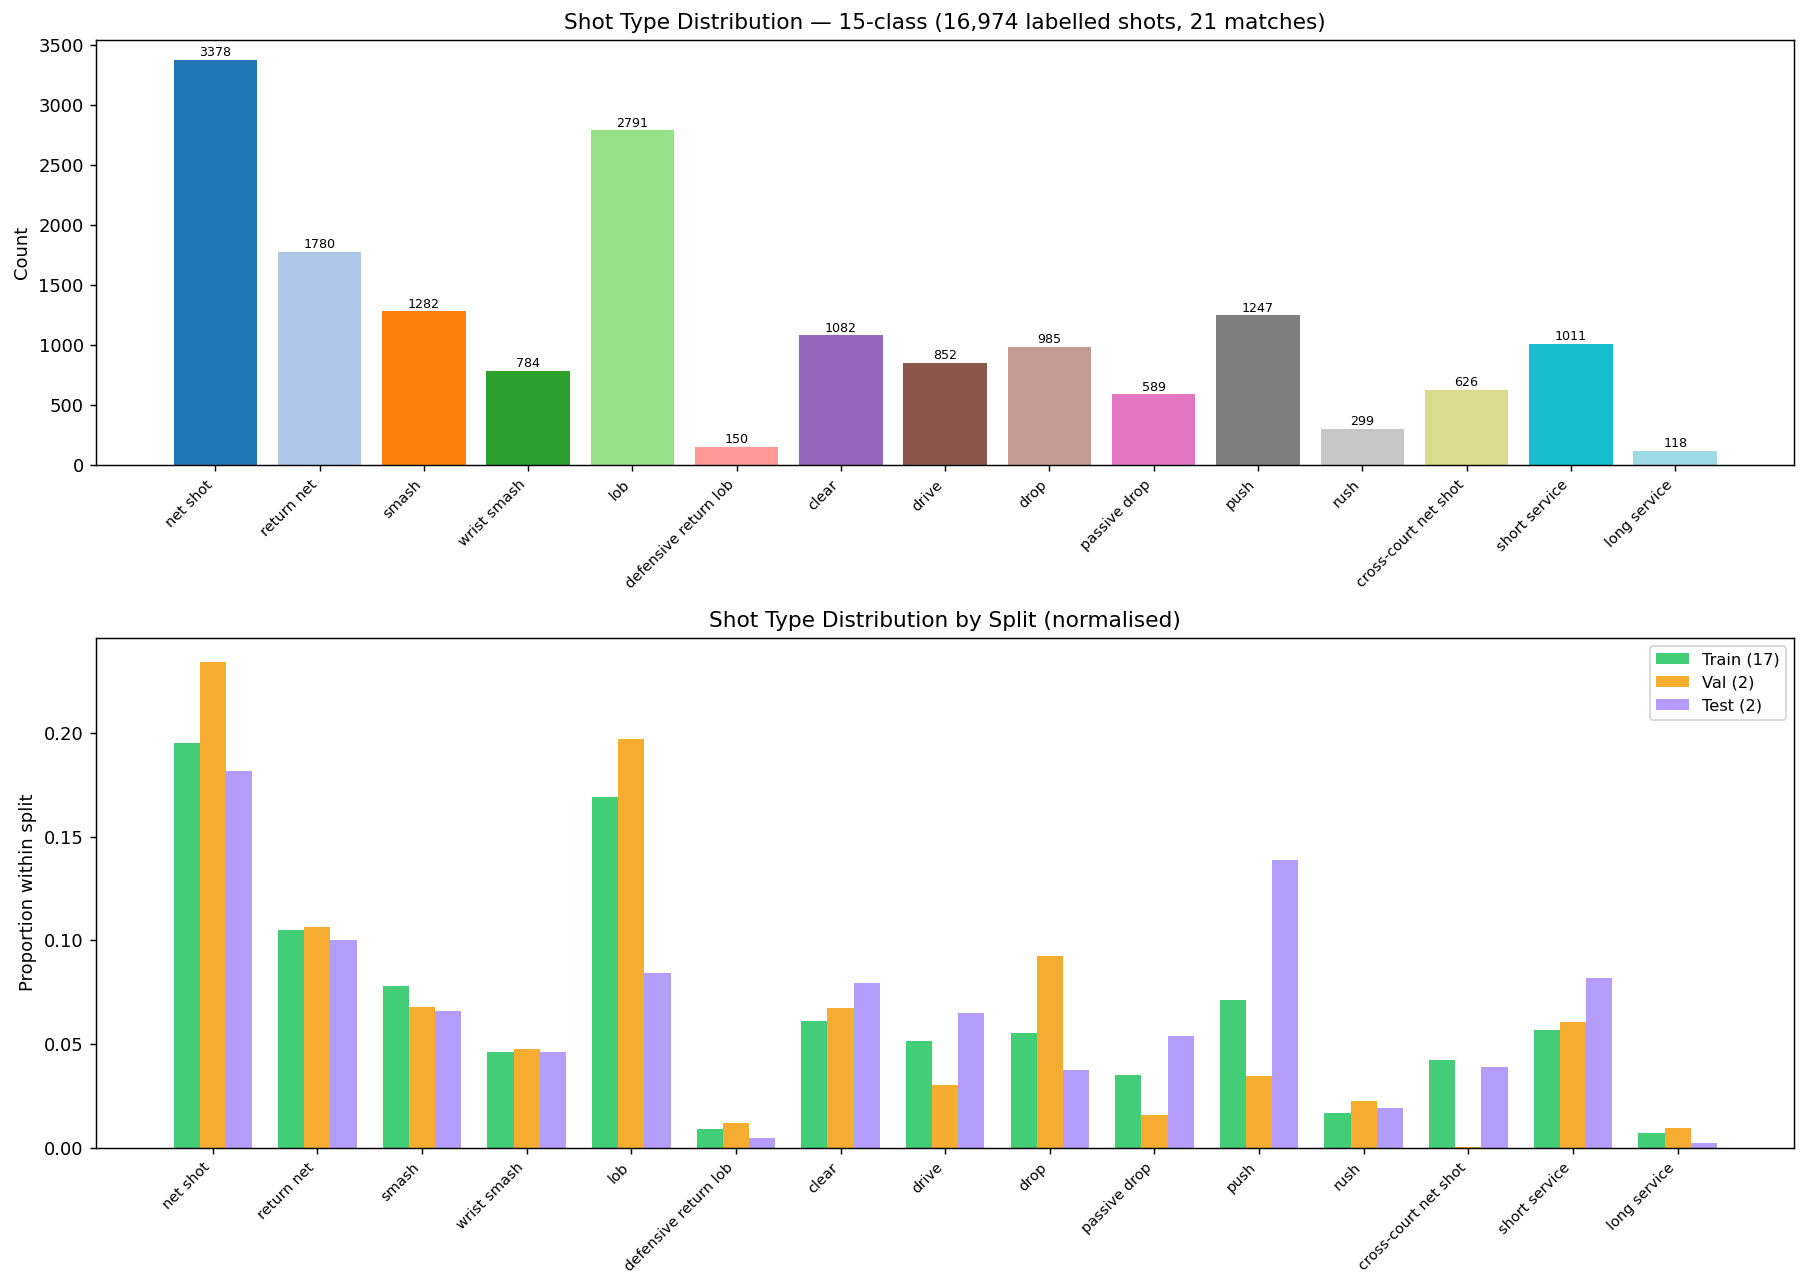

Imbalance ratio (max/min): 28.6x

Shot type                   Count      %
----------------------------------------
  net shot                   3378   19.9%
  return net                 1780   10.5%
  smash                      1282    7.6%
  wrist smash                 784    4.6%
  lob                        2791   16.4%
  defensive return lob        150    0.9%
  clear                      1082    6.4%
  drive                       852    5.0%
  drop                        985    5.8%
  passive drop                589    3.5%
  push                       1247    7.3%
  rush                        299    1.8%
  cross-court net shot        626    3.7%
  short service              1011    6.0%
  long service                118    0.7%
  TOTAL                     16974


In [4]:
labelled = strokes[strokes['shot_type'].notna()].copy()

# Counts in SHOT_TYPES order
type_counts = labelled['shot_type'].value_counts()
ordered_counts = [type_counts.get(s, 0) for s in SHOT_TYPES]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1.2]})

# Overall bar chart
colors = plt.cm.tab20(np.linspace(0, 1, len(SHOT_TYPES)))
bars = axes[0].bar(range(len(SHOT_TYPES)), ordered_counts, color=colors)
axes[0].set_xticks(range(len(SHOT_TYPES)))
axes[0].set_xticklabels(SHOT_TYPES, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Count')
axes[0].set_title(f'Shot Type Distribution — 15-class ({labelled.shape[0]:,} labelled shots, 21 matches)')
for bar, cnt in zip(bars, ordered_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(cnt), ha='center', va='bottom', fontsize=7)

# Per-split normalised
split_type = labelled.groupby(['split','shot_type']).size().unstack(fill_value=0)
split_type = split_type.reindex(index=['train','val','test'], columns=SHOT_TYPES, fill_value=0)
split_pct  = split_type.div(split_type.sum(axis=1), axis=0)

x = np.arange(len(SHOT_TYPES))
w = 0.25
for i, sp in enumerate(['train','val','test']):
    axes[1].bar(x + (i-1)*w, split_pct.loc[sp].values, w,
                label=SPLIT_LABELS[sp], color=SPLIT_COLORS[sp], alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(SHOT_TYPES, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Proportion within split')
axes[1].set_title('Shot Type Distribution by Split (normalised)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

total_labelled = sum(ordered_counts)
imbalance = max(ordered_counts) / min(c for c in ordered_counts if c > 0)
print(f"Imbalance ratio (max/min): {imbalance:.1f}x")
print(f"\n{'Shot type':<26} {'Count':>6}  {'%':>5}")
print("-"*40)
for s, n in zip(SHOT_TYPES, ordered_counts):
    print(f"  {s:<24} {n:6d}  {n/total_labelled*100:5.1f}%")
print(f"  {'TOTAL':<24} {total_labelled:6d}")

## 4. Per-Match Shot Counts Heatmap

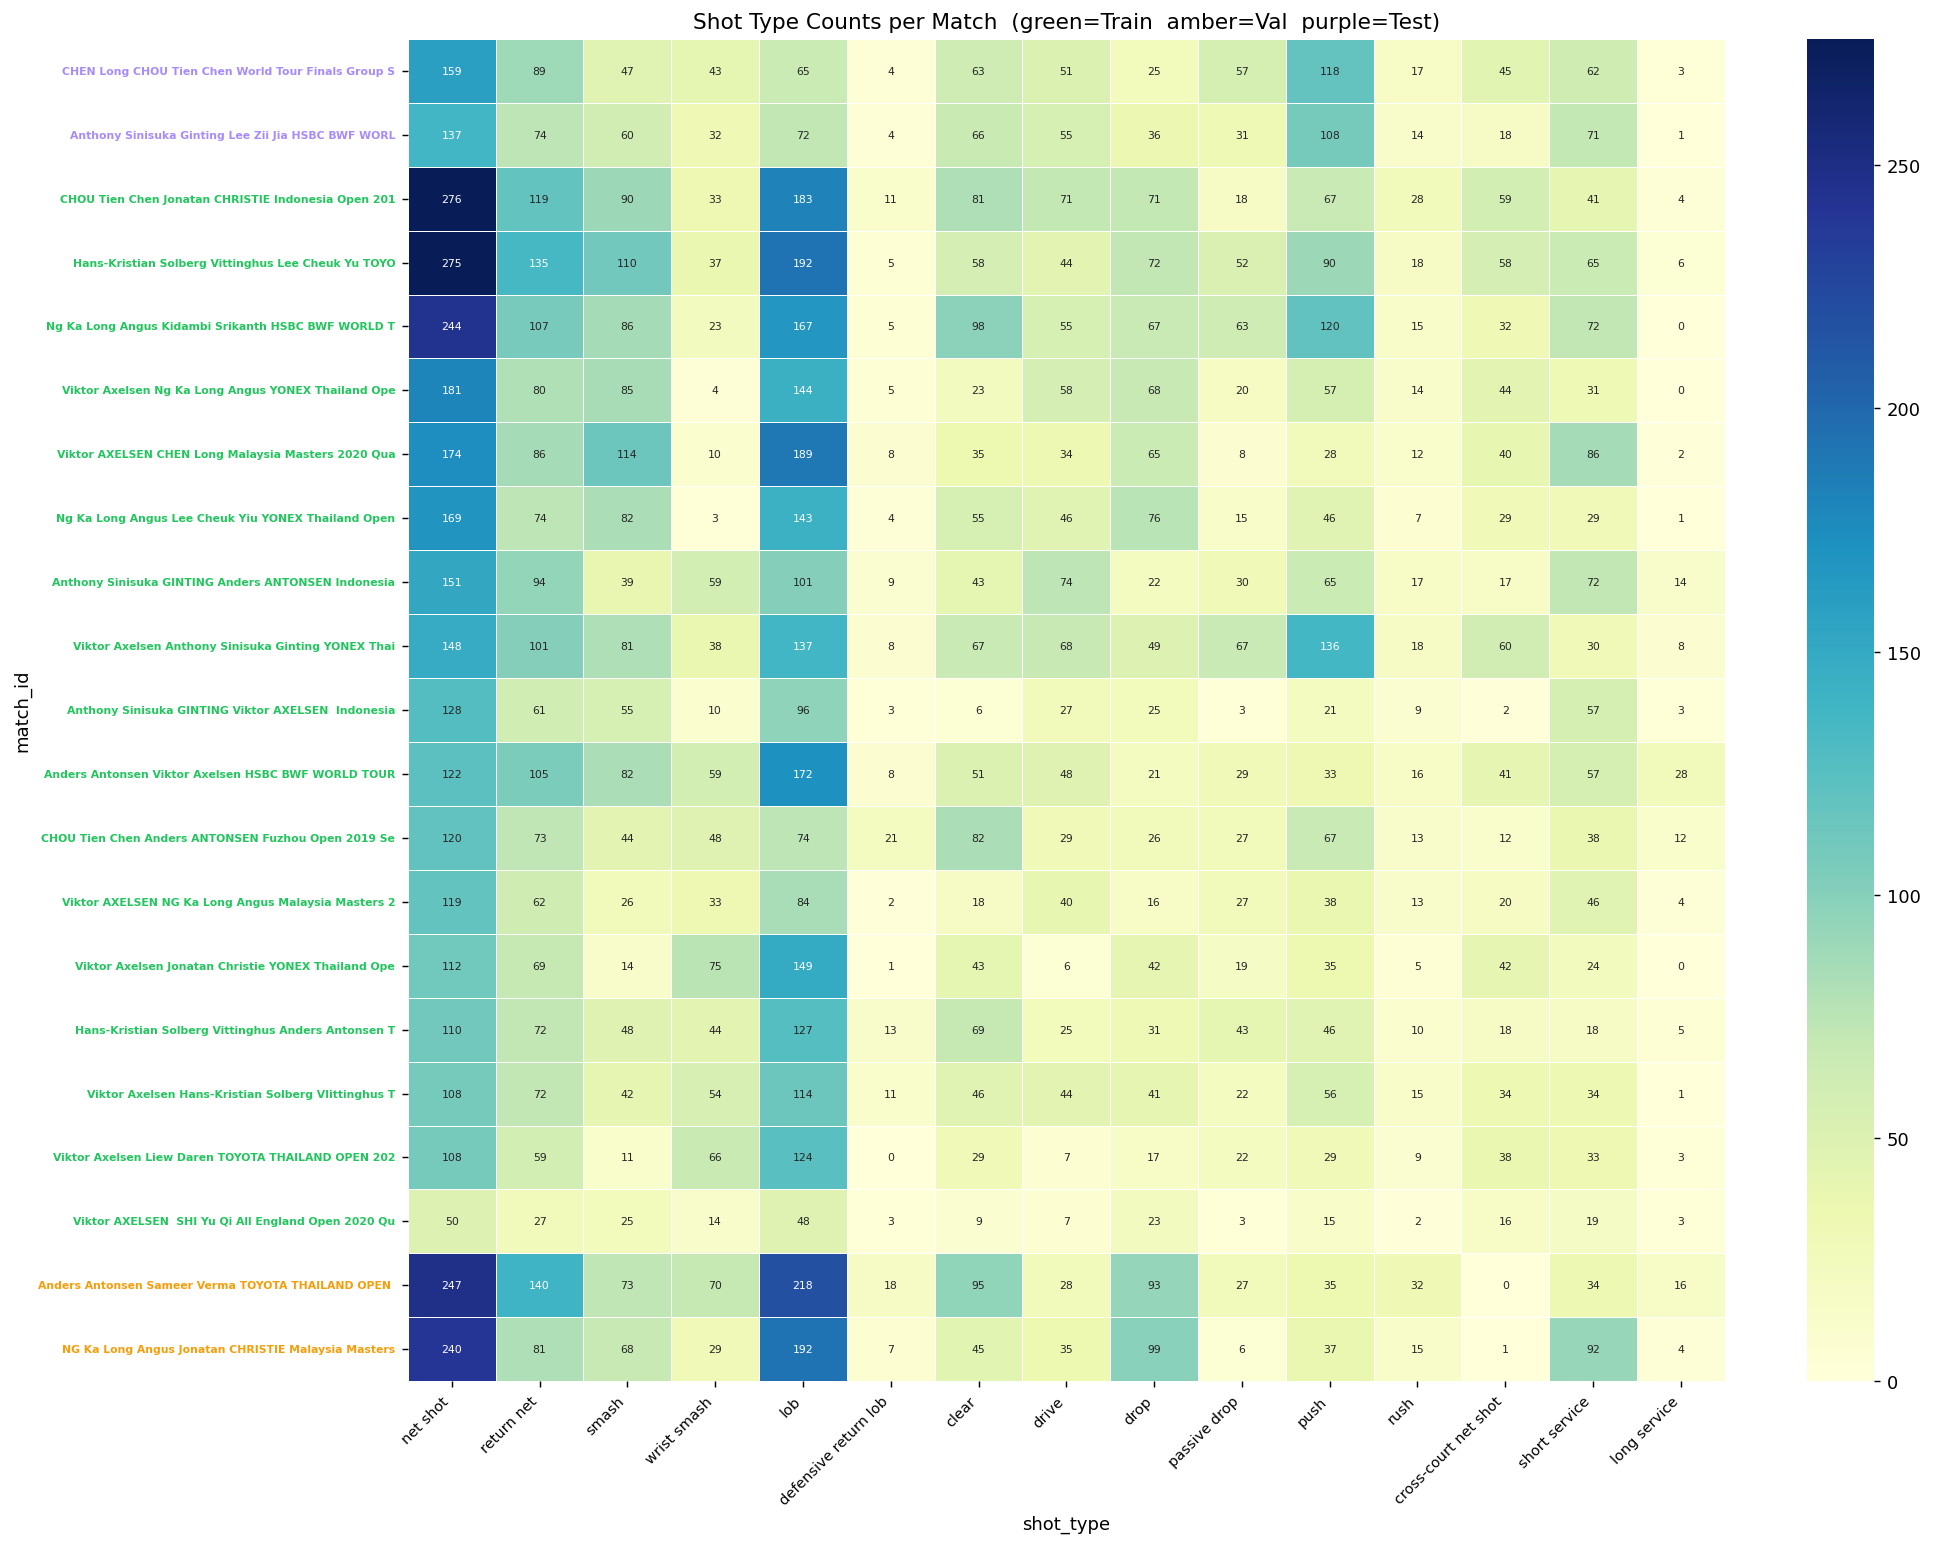

In [5]:
spm = labelled.groupby(['match_id','shot_type']).size().unstack(fill_value=0)
spm = spm.reindex(columns=SHOT_TYPES, fill_value=0)

split_map = strokes.groupby('match_id')['split'].first()
spm['_split'] = spm.index.map(split_map)
spm = spm.sort_values(['_split', 'net shot'], ascending=[True, False])
split_labels_row = spm['_split'].values
spm = spm.drop(columns='_split')

row_labels = [m.replace('_',' ')[:50] for m in spm.index]
row_colors = [SPLIT_COLORS.get(s, '#888') for s in split_labels_row]

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(spm, annot=True, fmt='d', cmap='YlGnBu',
            ax=ax, linewidths=0.3, annot_kws={'size': 6})
ax.set_yticklabels(row_labels, fontsize=6)
for label, color in zip(ax.get_yticklabels(), row_colors):
    label.set_color(color)
    label.set_fontweight('bold')
ax.set_title('Shot Type Counts per Match  (green=Train  amber=Val  purple=Test)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## 5. Rally Length Distribution

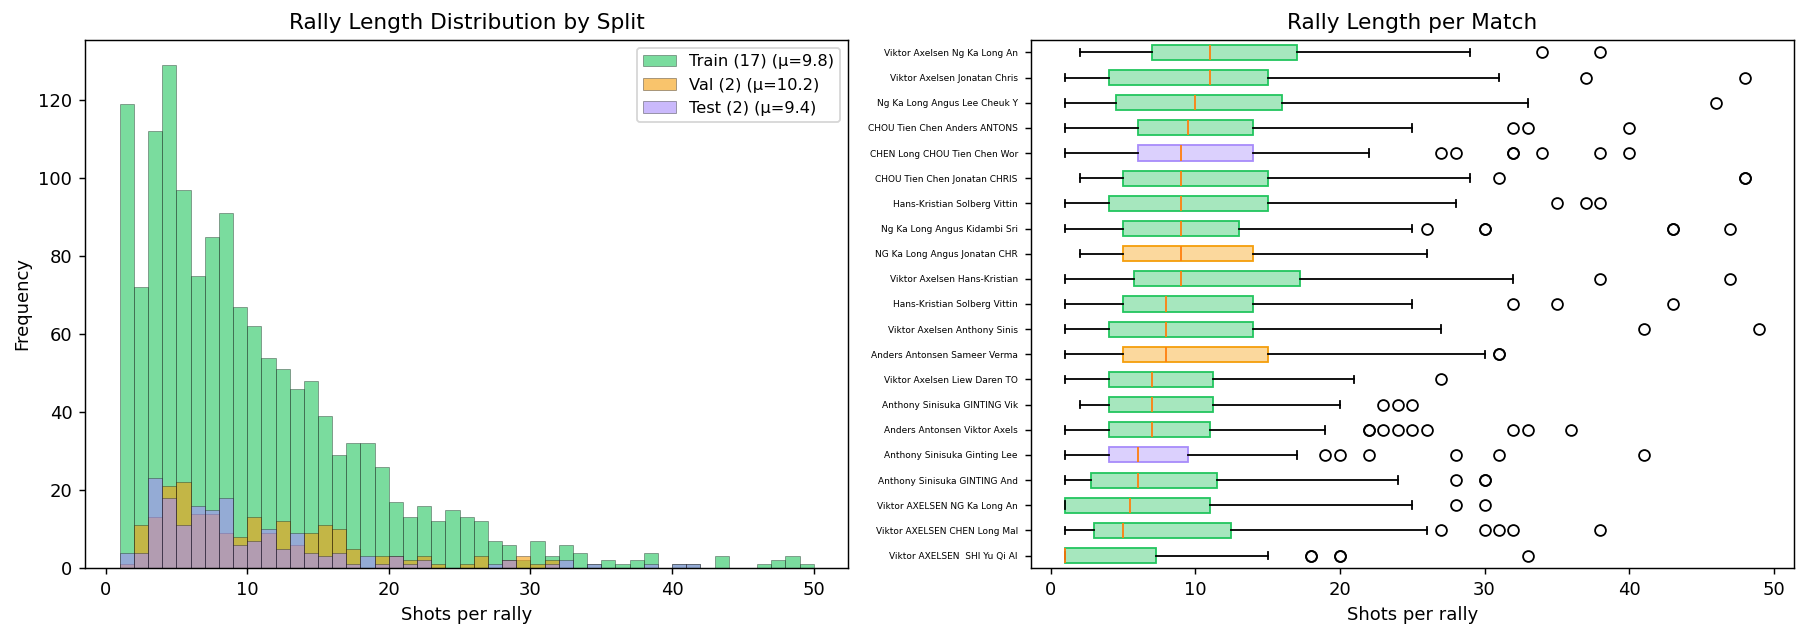

Total rallies: 1,811
Shots/rally — min: 1, median: 8, mean: 9.8, max: 49


In [6]:
# Set-aware rally grouping
rally_len = (strokes.groupby(['split','match_id','rally_uid'])
             .size().reset_index(name='n_shots'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sp in ('train', 'val', 'test'):
    sub = rally_len[rally_len['split'] == sp]
    axes[0].hist(sub['n_shots'], bins=range(1, rally_len['n_shots'].max() + 2),
                 alpha=0.6, label=f"{SPLIT_LABELS[sp]} (μ={sub['n_shots'].mean():.1f})",
                 color=SPLIT_COLORS[sp], edgecolor='black', linewidth=0.3)
axes[0].set_xlabel('Shots per rally')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Rally Length Distribution by Split')
axes[0].legend(fontsize=9)

match_order = rally_len.groupby('match_id')['n_shots'].median().sort_values().index
bp = axes[1].boxplot(
    [rally_len[rally_len['match_id'] == m]['n_shots'].values for m in match_order],
    vert=False, patch_artist=True, widths=0.6)
for i, m in enumerate(match_order):
    sp = active_matches[m]
    bp['boxes'][i].set_facecolor(SPLIT_COLORS[sp] + '66')
    bp['boxes'][i].set_edgecolor(SPLIT_COLORS[sp])
axes[1].set_yticklabels([m.replace('_',' ')[:28] for m in match_order], fontsize=5)
axes[1].set_xlabel('Shots per rally')
axes[1].set_title('Rally Length per Match')

plt.tight_layout()
plt.show()

print(f"Total rallies: {len(rally_len):,}")
print(f"Shots/rally — min: {rally_len['n_shots'].min()}, "
      f"median: {rally_len['n_shots'].median():.0f}, "
      f"mean: {rally_len['n_shots'].mean():.1f}, "
      f"max: {rally_len['n_shots'].max()}")

## 6. Shot Duration by Type

Shot duration pairs: 15,798
Duration (s) — median: 0.83, mean: 0.85, max: 24.93


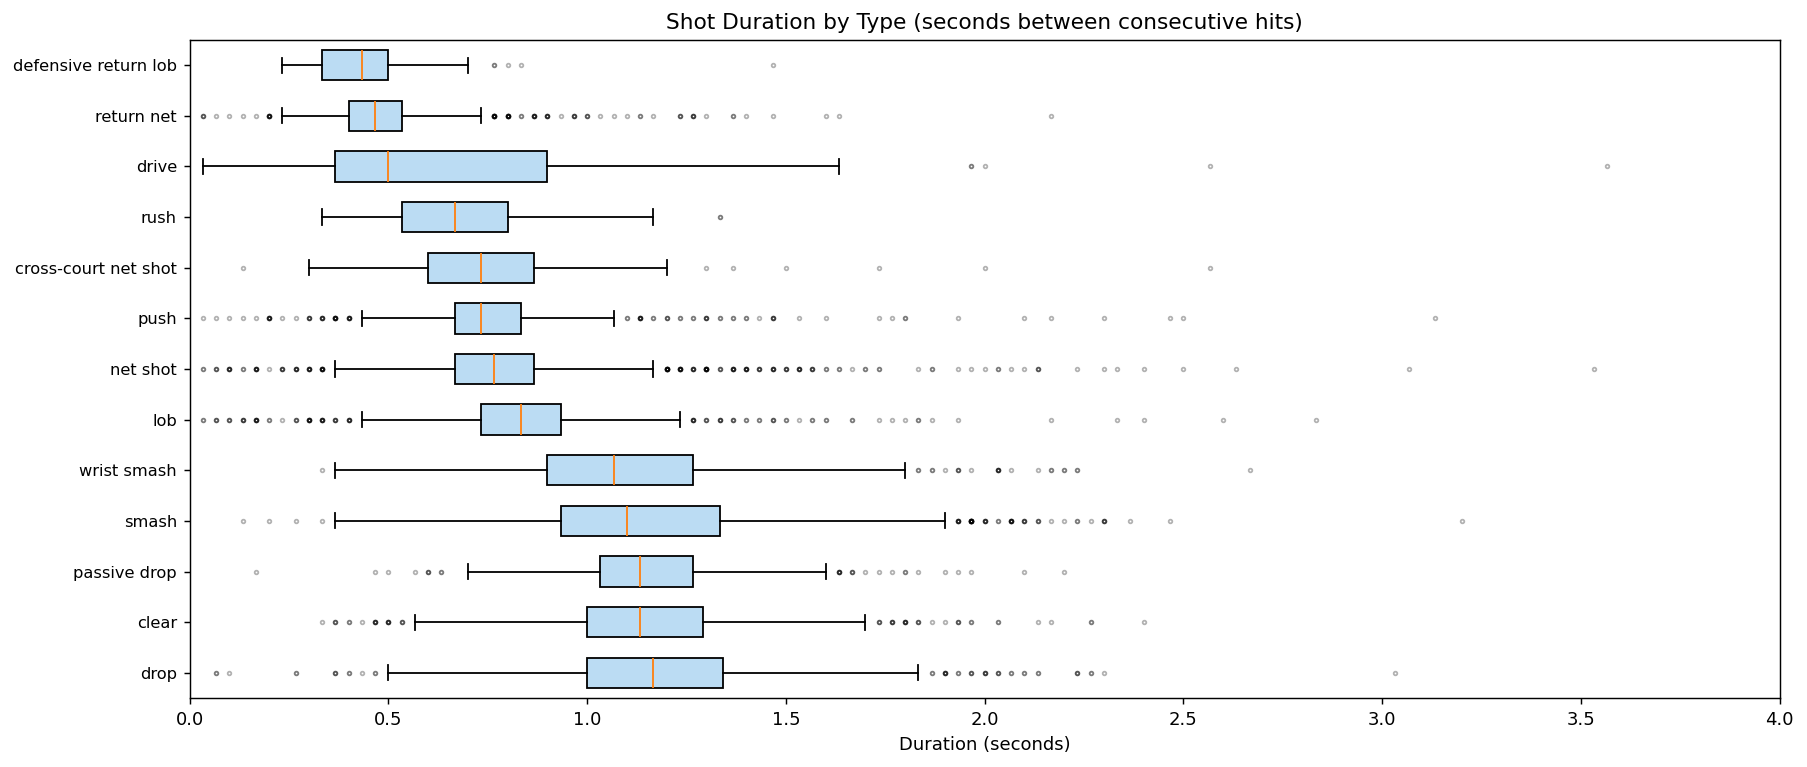


Shot type                      n   median     mean     std
-------------------------------------------------------
  drop                       984     1.17     1.21    0.83
  clear                     1082     1.13     1.15    0.27
  passive drop               589     1.13     1.16    0.21
  smash                     1281     1.10     1.16    0.36
  wrist smash                782     1.07     1.10    0.32
  lob                       2784     0.83     0.83    0.19
  net shot                  3364     0.77     0.78    0.24
  push                      1243     0.73     0.76    0.22
  cross-court net shot       626     0.73     0.72    0.21
  rush                       299     0.67     0.67    0.17
  drive                      850     0.50     0.64    0.35
  return net                1764     0.47     0.48    0.45
  defensive return lob       150     0.43     0.45    0.15


In [7]:
FPS = 30
durations = []
for (match_id, rally_uid), grp in strokes.groupby(['match_id','rally_uid']):
    grp = grp.sort_values('ball_round')
    frames = grp['frame_num'].values
    types  = grp['shot_type'].values
    sp     = grp['split'].iloc[0]
    for i in range(1, len(frames)):
        if pd.isna(frames[i]) or pd.isna(frames[i-1]): continue
        gap = frames[i] - frames[i-1]
        if gap <= 0 or pd.isna(types[i]): continue
        durations.append({'split': sp, 'shot_type': types[i],
                          'duration_s': gap / FPS})

dur_df = pd.DataFrame(durations)
print(f"Shot duration pairs: {len(dur_df):,}")
print(f"Duration (s) — median: {dur_df['duration_s'].median():.2f}, "
      f"mean: {dur_df['duration_s'].mean():.2f}, "
      f"max: {dur_df['duration_s'].max():.2f}")

type_order = dur_df.groupby('shot_type')['duration_s'].median().reindex(SHOT_TYPES).sort_values(ascending=False).dropna().index

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(
    [dur_df[dur_df['shot_type'] == t]['duration_s'].values for t in type_order],
    vert=False, patch_artist=True, widths=0.6,
    flierprops=dict(markersize=2, alpha=0.3))
for box in bp['boxes']:
    box.set_facecolor('#3498db55')
ax.set_yticklabels(type_order, fontsize=9)
ax.set_xlabel('Duration (seconds)')
ax.set_title('Shot Duration by Type (seconds between consecutive hits)')
ax.set_xlim(0, 4)
plt.tight_layout()
plt.show()

print(f"\n{'Shot type':<26} {'n':>5}  {'median':>7}  {'mean':>7}  {'std':>6}")
print("-"*55)
for t in type_order:
    sub = dur_df[dur_df['shot_type'] == t]['duration_s']
    print(f"  {t:<24} {len(sub):5d}  {sub.median():7.2f}  {sub.mean():7.2f}  {sub.std():6.2f}")

## 7. Class Imbalance Analysis

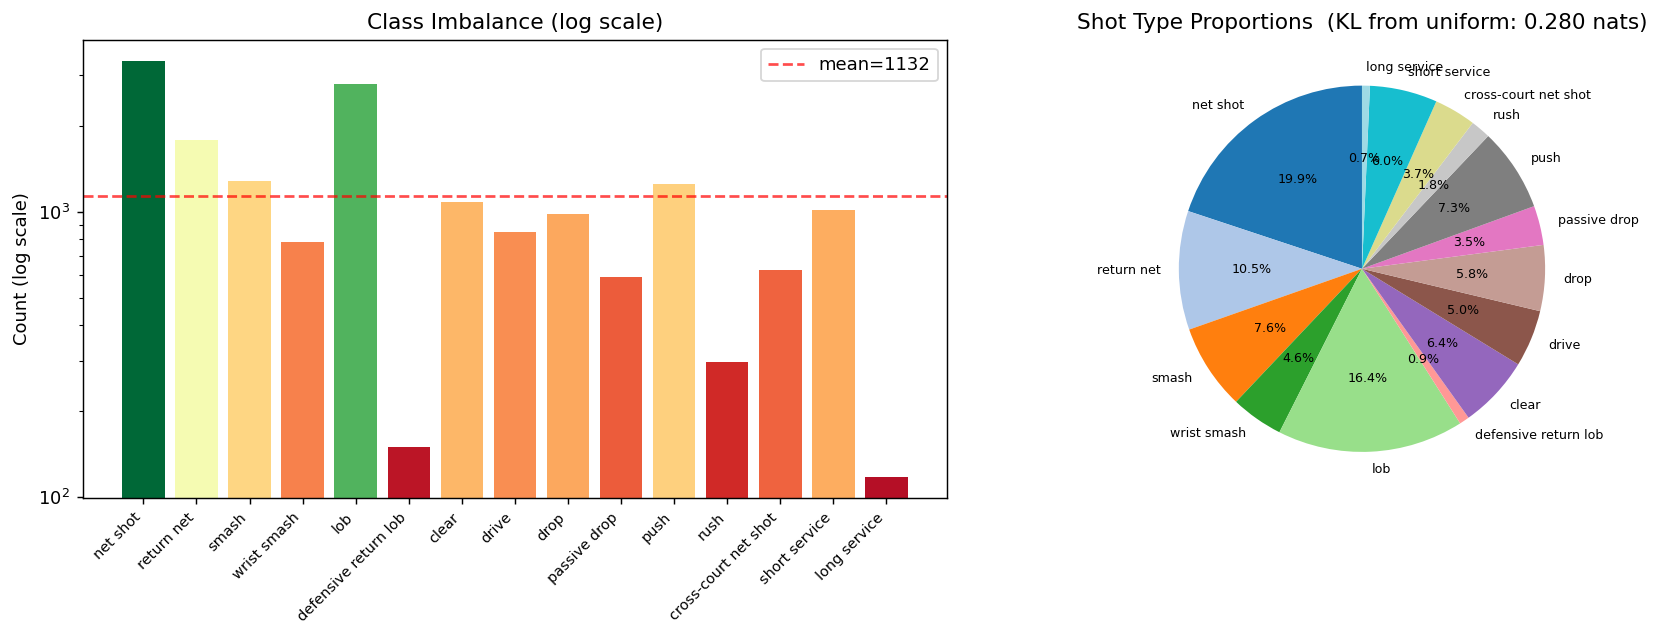

Shot type                   Count      %  vs_uniform
  net shot                   3378   19.9%       +3.0x
  lob                        2791   16.4%       +2.5x
  return net                 1780   10.5%       +1.6x
  smash                      1282    7.6%       +1.1x
  push                       1247    7.3%       +1.1x
  clear                      1082    6.4%       +1.0x
  short service              1011    6.0%       +0.9x
  drop                        985    5.8%       +0.9x
  drive                       852    5.0%       +0.8x
  wrist smash                 784    4.6%       +0.7x
  cross-court net shot        626    3.7%       +0.6x
  passive drop                589    3.5%       +0.5x
  rush                        299    1.8%       +0.3x
  defensive return lob        150    0.9%       +0.1x
  long service                118    0.7%       +0.1x

Imbalance ratio: 28.6x
KL divergence from uniform: 0.2798 nats


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale bar chart
ordered_counts_arr = np.array(ordered_counts)
colors_bar = plt.cm.RdYlGn(ordered_counts_arr / ordered_counts_arr.max())
axes[0].bar(range(len(SHOT_TYPES)), ordered_counts_arr, color=colors_bar)
axes[0].set_yscale('log')
axes[0].set_xticks(range(len(SHOT_TYPES)))
axes[0].set_xticklabels(SHOT_TYPES, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Class Imbalance (log scale)')
axes[0].axhline(np.mean(ordered_counts_arr), color='red', ls='--', alpha=0.7, label=f'mean={np.mean(ordered_counts_arr):.0f}')
axes[0].legend()

# KL divergence from uniform
from scipy.stats import entropy
uniform = np.ones(len(SHOT_TYPES)) / len(SHOT_TYPES)
p = ordered_counts_arr / ordered_counts_arr.sum()
kl = entropy(p, uniform)
axes[1].pie(ordered_counts_arr, labels=SHOT_TYPES, autopct='%1.1f%%',
            startangle=90, colors=plt.cm.tab20(np.linspace(0, 1, len(SHOT_TYPES))),
            textprops={'fontsize': 7})
axes[1].set_title(f'Shot Type Proportions  (KL from uniform: {kl:.3f} nats)')

plt.tight_layout()
plt.show()

# Counts sorted
print(f"{'Shot type':<26} {'Count':>6}  {'%':>5}  {'vs_uniform':>10}")
avg = total_labelled / len(SHOT_TYPES)
for s, n in sorted(zip(SHOT_TYPES, ordered_counts), key=lambda x: -x[1]):
    print(f"  {s:<24} {n:6d}  {n/total_labelled*100:5.1f}%  {n/avg:+9.1f}x")
print(f"\nImbalance ratio: {max(ordered_counts)/min(c for c in ordered_counts if c>0):.1f}x")
print(f"KL divergence from uniform: {kl:.4f} nats")

## 8. Summary

In [9]:
all_players = pd.concat([match_meta['winner'], match_meta['loser']]).value_counts()

print("=" * 65)
print("EDA SUMMARY — 21 Matches, 15-class vocabulary")
print("=" * 65)
for sp in ('train', 'val', 'test'):
    n_m  = sum(1 for v in active_matches.values() if v == sp)
    n_r  = rally_len[rally_len['split'] == sp]['rally_uid'].nunique()
    n_s  = int(strokes[strokes['split'] == sp].shape[0])
    n_l  = int(strokes[strokes['split'] == sp]['shot_type'].notna().sum())
    print(f"  {sp:6s}: {n_m} matches  {n_r} rallies  {n_s:,} shots  ({n_l:,} labelled)")
print(f"\nTotal shots          : {len(strokes):,}")
print(f"Labelled shots       : {total_labelled:,}")
print(f"Unknown (skipped)    : {strokes['shot_type'].isna().sum():,}")
print(f"Unique shot types    : {NUM_SHOT_TYPES} (15-class, drive merged)")
print(f"Avg shots/rally      : {rally_len['n_shots'].mean():.1f}")
print(f"Imbalance ratio      : {max(ordered_counts)/min(c for c in ordered_counts if c>0):.1f}x")
print(f"Unique players       : {len(all_players)}")
print(f"\nDrive merge: 平球({type_counts.get('drive',0)} after merge)")
print("  平球 + 後場抽平球 + 防守回抽 + 小平球 → drive")
print("=" * 65)

EDA SUMMARY — 21 Matches, 15-class vocabulary
  train : 17 matches  123 rallies  13,924 shots  (13,270 labelled)
  val   : 2 matches  118 rallies  2,155 shots  (2,077 labelled)
  test  : 2 matches  110 rallies  1,675 shots  (1,627 labelled)

Total shots          : 17,754
Labelled shots       : 16,974
Unknown (skipped)    : 780
Unique shot types    : 15 (15-class, drive merged)
Avg shots/rally      : 9.8
Imbalance ratio      : 28.6x
Unique players       : 14

Drive merge: 平球(852 after merge)
  平球 + 後場抽平球 + 防守回抽 + 小平球 → drive
